# Run experiments (notebook runner)

Uruchamiamy eksperymenty z `src/experiments` **jeden po jednym** i pokazujemy ich wyniki (stdout/stderr + wykresy) bez zapisywania plików na dysk.

Kolejność (będziemy dodawać kolejne sekcje):
1. `TimeInconsistencyApple.py`
2. `DecisionMAkingShop.py`
3. `two_state_counterexample.py`
4. `two_state_qlearning.py`
5. `InventoryMDP.py`

In [22]:
from __future__ import annotations

import contextlib
import io
import runpy
import sys
from pathlib import Path


def find_repo_root(start: Path | None = None) -> Path:
    """Find the repo root by searching upwards for the `src/` directory."""
    here = (start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(f"Could not find repo root starting from {here}")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)
print("Python:", sys.version.split()[0])


def run_module_inline_no_savefig(module: str) -> str:
    """Run a module (like `python -m ...`) and show plots inline instead of saving PNGs."""
    import matplotlib.pyplot as plt
    from IPython.display import display

    original_savefig = plt.savefig
    buf_out = io.StringIO()
    buf_err = io.StringIO()

    def _patched_savefig(*_args, **_kwargs):
        fig = plt.gcf()
        display(fig)
        plt.close(fig)
        return None

    try:
        plt.savefig = _patched_savefig  # type: ignore[assignment]
        with contextlib.redirect_stdout(buf_out), contextlib.redirect_stderr(buf_err):
            runpy.run_module(module, run_name="__main__")
    finally:
        plt.savefig = original_savefig  # type: ignore[assignment]
        try:
            plt.close("all")
        except Exception:
            pass

    out = buf_out.getvalue()
    err = buf_err.getvalue()
    out = out + ("\n\n[stderr]\n" + (err.rstrip() if err else "(empty)"))
    return out

REPO_ROOT: /run/media/mwrona/Nowy/Engineering-Thesis
Python: 3.14.2


## 1) `TimeInconsistencyApple.py`

Ten skrypt ma kod w top-level, więc uruchamiamy go jako moduł.
Wykresy są przechwytywane: zamiast `plt.savefig(...)` wyświetlamy je w notebooku.

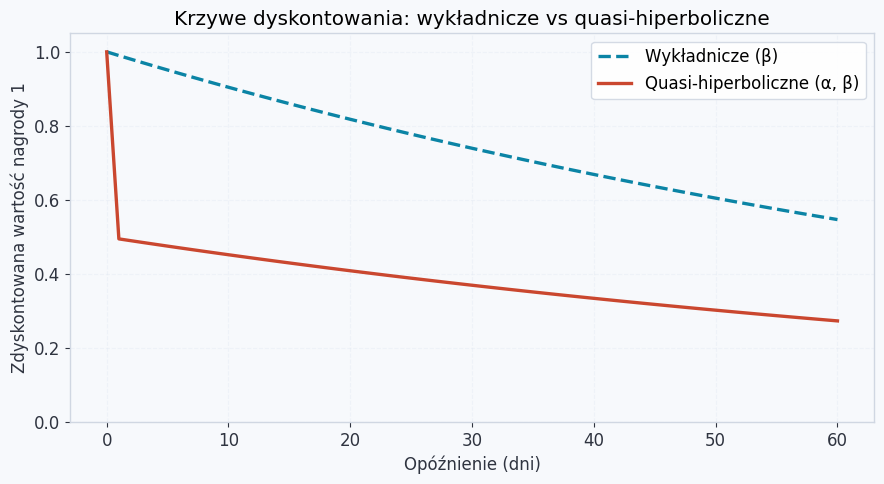

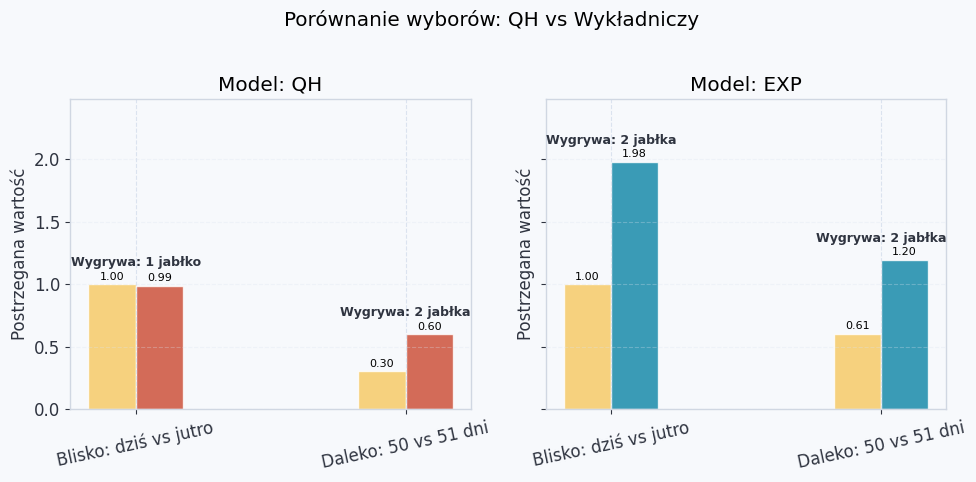

Scenariusz                   | ds  dl  | QH 1j      QH 2j      QH wybór   | EXP 1j     EXP 2j     EXP wybór 
------------------------------------------------------------------------------------------------------------------------
Blisko: dziś vs jutro        | 0   1   | 1.0000     0.9900     1 jabłko   | 1.0000     1.9800     2 jabłka  
Daleko: 50 vs 51 dni         | 50  51  | 0.3025     0.5990     2 jabłka   | 0.6050     1.1979     2 jabłka  


[stderr]
(empty)


In [3]:
out = run_module_inline_no_savefig("src.experiments.TimeInconsistencyApple")
print(out)

## 2) `DecisionMAkingShop.py`

Skrypt zapisuje wykresy przez `plt.savefig(...)`, ale w notebooku przechwytujemy to i pokazujemy wykresy inline (bez zapisu na dysk).

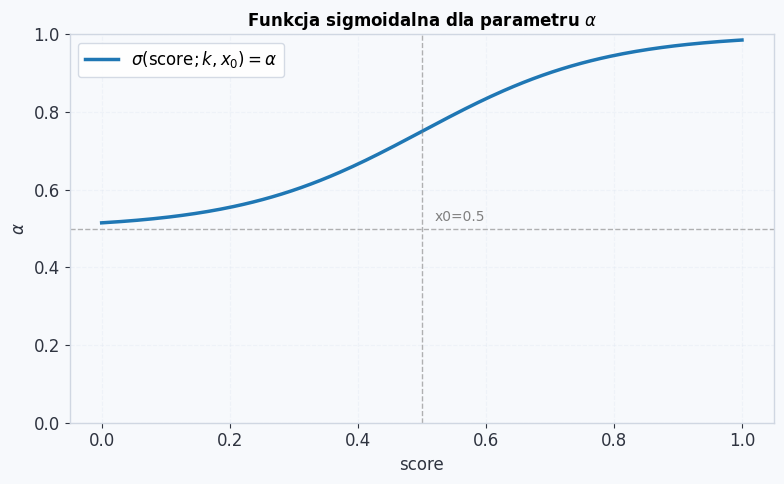

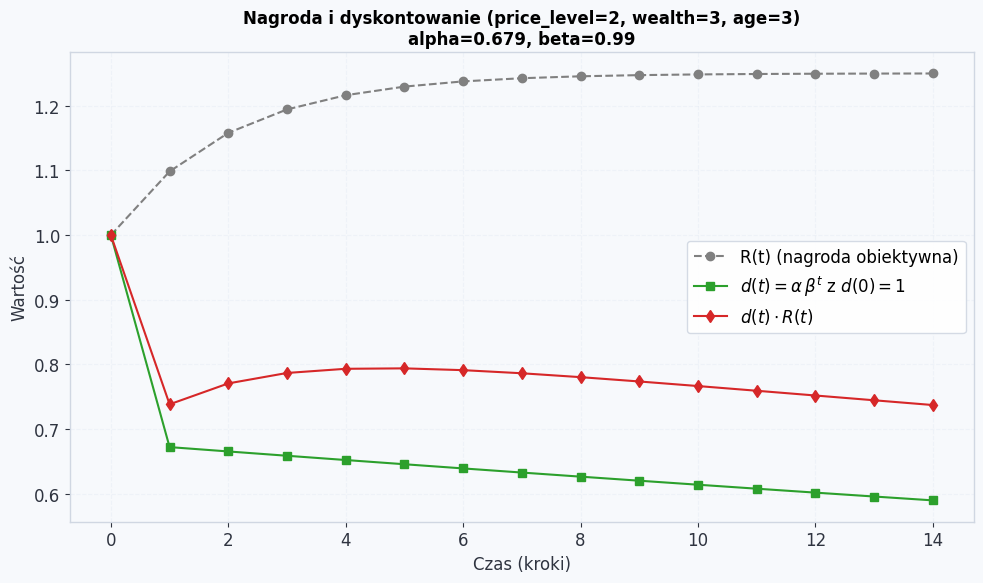

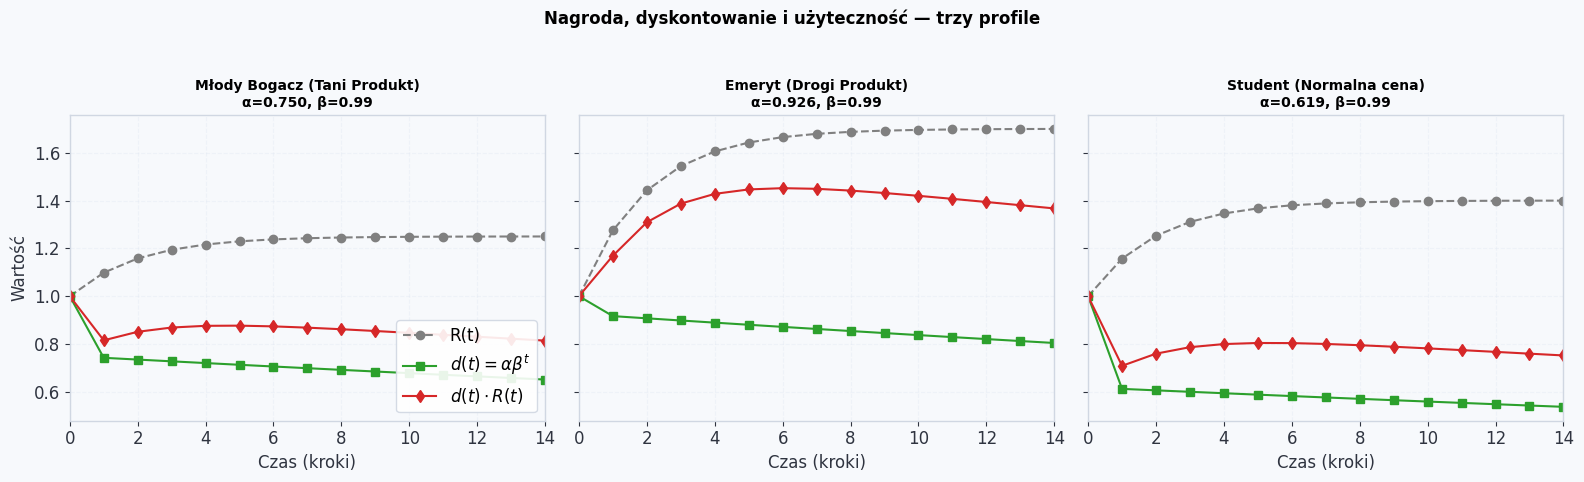

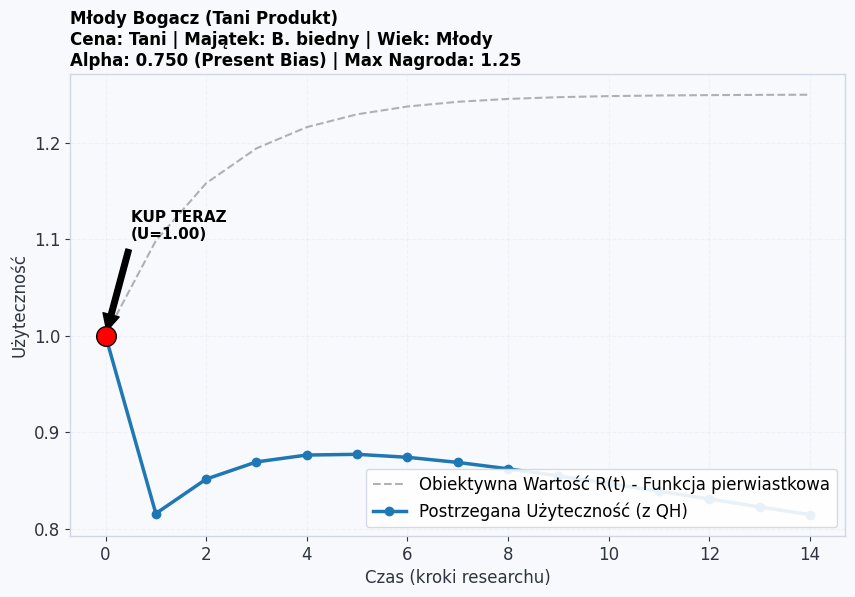

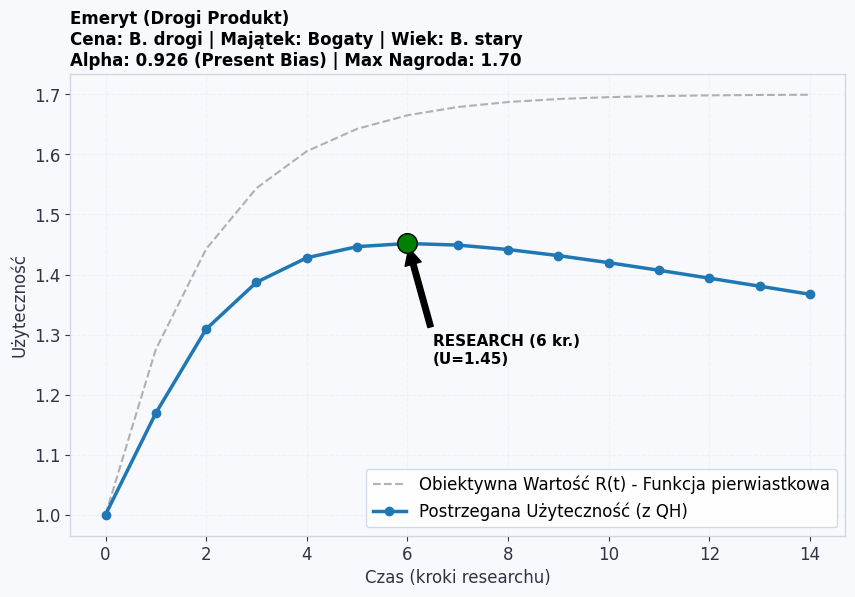

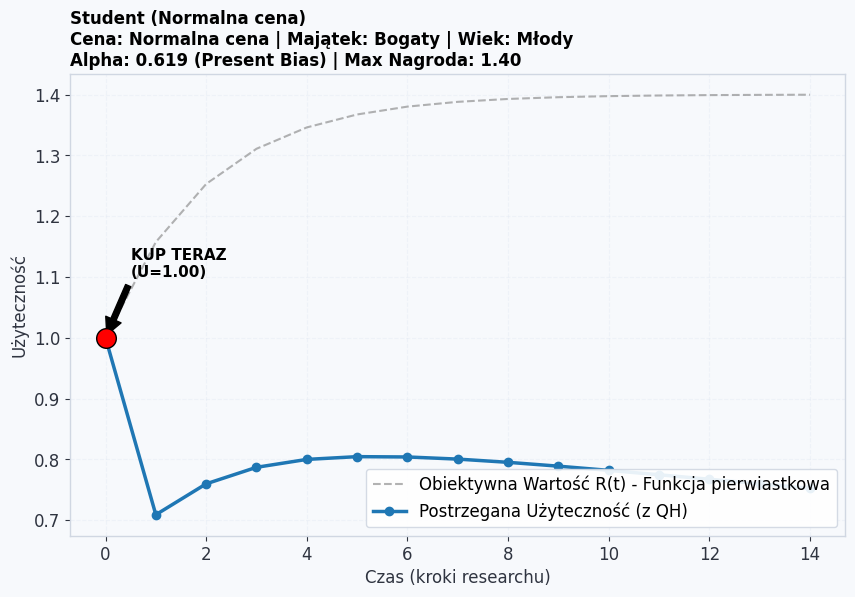

price_level,price_label,wealth_level,wealth_label,age_level,age_label,alpha,decision,best_step
1,B. tani,1,B. bogaty,1,B. młody,0.515,KUP TERAZ,0
1,B. tani,1,B. bogaty,2,Młody,0.526,KUP TERAZ,0
1,B. tani,1,B. bogaty,3,Średni wiek,0.544,KUP TERAZ,0
1,B. tani,1,B. bogaty,4,Stary,0.574,KUP TERAZ,0
1,B. tani,1,B. bogaty,5,B. stary,0.619,KUP TERAZ,0
1,B. tani,2,Bogaty,1,B. młody,0.526,KUP TERAZ,0
1,B. tani,2,Bogaty,2,Młody,0.544,KUP TERAZ,0
1,B. tani,2,Bogaty,3,Średni wiek,0.574,KUP TERAZ,0
1,B. tani,2,Bogaty,4,Stary,0.619,KUP TERAZ,0
1,B. tani,2,Bogaty,5,B. stary,0.679,KUP TERAZ,0
1,B. tani,3,Normalny,1,B. młody,0.544,KUP TERAZ,0
1,B. tani,3,Normalny,2,Młody,0.574,KUP TERAZ,0
1,B. tani,3,Normalny,3,Średni wiek,0.619,KUP TERAZ,0
1,B. tani,3,Normalny,4,Stary,0.679,KUP TERAZ,0
1,B. tani,3,Normalny,5,B. stary,0.750,KUP TERAZ,0
1,B. tani,4,Biedny,1,B. młody,0.574,KUP TERAZ,0
1,B. tani,4,Biedny,2,Młody,0.619,KUP TERAZ,0
1,B. tani,4,Biedny,3,Średni wiek,0.679,KUP TERAZ,0
1,B. tani,4,Biedny,4,Star

In [16]:
out = run_module_inline_no_savefig("src.experiments.DecisionMAkingShop")
print(out)

## 3) `two_state_counterexample.py`

Uruchomienie 1:1 jak w skrypcie (domyślnie **bardzo długi** bieg: `n_sweeps = 10_000_000` dla 3 polityk).
Wyniki pojawią się jako tabela na stdout.

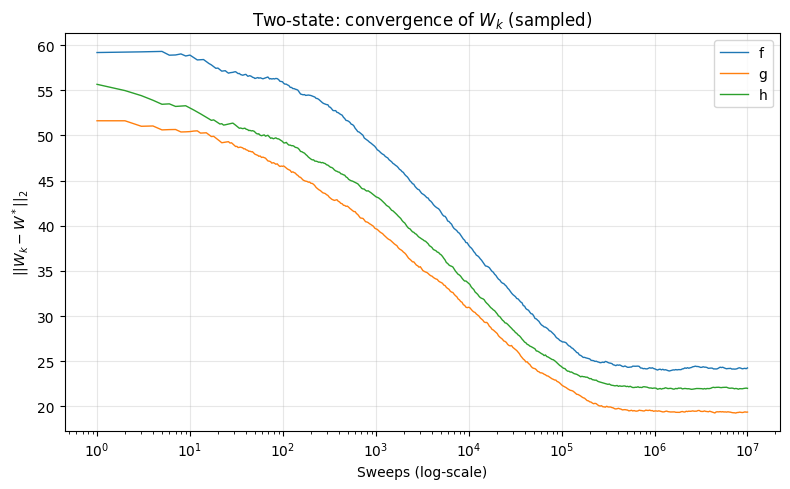

--- Reproducing Table 1c (alpha=0.5, beta=0.8) ---
Pair       | f (Target)   | g (Target)   | h (Target)  
--------------------------------------------------
Policy f [################################] 100.00% (10,000,000/10,000,000) | ETA: 0ss
Policy g [################################] 100.00% (10,000,000/10,000,000) | ETA: 0ss
Policy h [################################] 100.00% (10,000,000/10,000,000) | ETA: 0ss
1, a1      | 18.82   (18.88) | 16.83   (16.83) | 18.03   (18.0)
1, a2      | 18.96   (19.0) | 16.70   (16.77) | 18.02   (18.0)
2, a1      | 32.09   (32.11) | 29.58   (29.56) | 31.00   (31.0)

Legenda: Wartość obliczona (Wartość z artykułu)


[stderr]
(empty)


In [14]:
out = run_module_inline_no_savefig("src.experiments.two_state_counterexample")
print(out)

## 3b) `two_state_five_policies.py` — Policy evaluation (Alg. 1)

Na razie **pomijamy**:
- closed-form liczenie tabeli $Q$ dla polityk
- QH Q-learning (Alg. 2)

Poniżej uruchamiamy tylko **model-free policy evaluation** (Alg. 1) dla 5 polityk.

In [2]:
from __future__ import annotations

import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for candidate in [start] + list(start.parents):
        if (candidate / "src").is_dir():
            return candidate
    raise RuntimeError("Could not locate repo root (missing 'src/' directory).")


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.experiments.two_state_five_policies import TwoStateNinePoliciesMDP

# Parametry zgodne z rozdziałem eksperymentów.
# W: wartość bazowa (czysto wykładnicza, dyskont β).
# J: wartość quasi-hiperboliczna (pierwszy krok wg μ, kontynuacja wg φ_s).
mdp = TwoStateNinePoliciesMDP(alpha=0.5, beta=0.9)

# -----------------------------------------------------------------------------
# GPU/Torch backend (optional CUDA)
# -----------------------------------------------------------------------------
try:
    import torch
except ImportError as exc:  # pragma: no cover
    raise ImportError(
        "Brak 'torch' w środowisku. Zainstaluj PyTorch (najlepiej z CUDA), np. 'pip install torch'."
    ) from exc

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
print(f"[torch] device={device}")


def _build_transition_reward_tensors():
    """Buduje tensory P[s,a,sp] i R3[s,a,sp] dla MDP (stany {1,2}, akcje {a1,a2})."""

    P_t = torch.zeros((2, 2, 2), device=device, dtype=dtype)
    R3_t = torch.zeros((2, 2, 2), device=device, dtype=dtype)

    for s_idx, s_mdp in enumerate([1, 2]):
        for a_idx, a_label in enumerate(["a1", "a2"]):
            dist = mdp.transitions[(s_mdp, a_label)]
            for sp_mdp, prob in dist.items():
                sp_idx = int(sp_mdp) - 1
                P_t[s_idx, a_idx, sp_idx] = float(prob)
                R3_t[s_idx, a_idx, sp_idx] = float(mdp.reward(s_mdp, a_label, int(sp_mdp)))

    return P_t, R3_t


P_t, R3_t = _build_transition_reward_tensors()

# Szybki bieg (na razie 100k).
n_sweeps = 1_000_000
n_log_points = 300

# Kroki uczące (Robbins–Monro): chcemy, żeby η_n i θ_n malały "wolno" -> wykładniki blisko 0.5.
# Jednocześnie wymagamy θ_exponent > η_exponent, żeby spełnić warunek dwóch skal czasowych (θ_n / η_n -> 0).
eta_step = 0.25
theta_step = 0.08
eta_exponent = 0.55
theta_exponent = 0.75

# Punkty logowania (log-spaced) dla czytelności na osi logarytmicznej.
log_idx = np.unique(np.logspace(0, np.log10(n_sweeps), n_log_points).astype(int))
log_idx[0] = 0
log_set = set(int(i) for i in log_idx)

plt.style.use("seaborn-v0_8")

nazwy_polityk_pl = {
    "always_a1": r"$\\varphi_1$: zawsze $a_1$",
    "always_a2": r"$\\varphi_2$: zawsze $a_2$",
    "a1_in_s1_a2_in_s2": r"$\\varphi_3$: $a_1$ w $s=1$, $a_2$ w $s=2$",
    "a2_in_s1_a1_in_s2": r"$\\varphi_4$: $a_2$ w $s=1$, $a_1$ w $s=2$",
    "fifty_fifty_both": r"$\\varphi_5$: losowa 50/50",
}


def _P_i_r_i(pol: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Indukuje (P_pol, r_pol) dla stanów {1,2} przy danej polityce (2x2).
    Akcje są w kolejności: a1, a2 (indeks 0 -> a1, 1 -> a2).
    """

    P_pol = np.zeros((2, 2), dtype=float)
    r_pol = np.zeros(2, dtype=float)
    for s_idx, s_mdp in enumerate([1, 2]):
        for a_idx, a_label in enumerate(["a1", "a2"]):
            p_a = float(pol[s_idx, a_idx])
            dist = mdp.transitions[(s_mdp, a_label)]
            for sp_mdp, prob in dist.items():
                P_pol[s_idx, int(sp_mdp) - 1] += p_a * float(prob)
                r_pol[s_idx] += p_a * float(prob) * float(mdp.reward(s_mdp, a_label, int(sp_mdp)))
    return P_pol, r_pol


def W_teoria(varphi_s: np.ndarray) -> np.ndarray:
    r"""Teoria dla W: czysto wykładnicza wartość pod kontynuacją φ_s.

    $$W = r_\\varphi + \\beta P_\\varphi W.$$"""

    P_phi, r_phi = _P_i_r_i(varphi_s)
    return np.linalg.solve(np.eye(2) - mdp.beta * P_phi, r_phi)


def J_teoria(mu: np.ndarray, varphi_s: np.ndarray, W_phi: np.ndarray) -> np.ndarray:
    r"""Teoria dla J (quasi-hiperboliczna) dla ρ=(μ,φ_s).

    Pierwszy krok jest zdyskontowany wagą 1, a kontynuacja od następnego stanu wagą αβ.
    $$J = r_\\mu + (\\alpha\\beta) P_\\mu W_{\\varphi}.$$"""

    P_mu, r_mu = _P_i_r_i(mu)
    return r_mu + (mdp.alpha * mdp.beta) * (P_mu @ W_phi)


def _nu_zapewnij_wsparcie(
    nu_bazowa: np.ndarray,
    mu: np.ndarray,
    varphi_s: np.ndarray,
    eps: float = 1e-2,
) -> np.ndarray:
    """Miesza nu z (mu, varphi_s), żeby zapewnić wspólne wsparcie dla wag istotności."""

    nu = (1.0 - 2.0 * eps) * nu_bazowa + eps * mu + eps * varphi_s
    return nu / nu.sum(axis=1, keepdims=True)


def _stepsizes(t: int) -> tuple[float, float]:
    eta_n = float(eta_step / ((1.0 + float(t)) ** eta_exponent))
    theta_n = float(theta_step / ((1.0 + float(t)) ** theta_exponent))
    return eta_n, theta_n


def uruchom_ewaluacje_z_historia(
    mu: np.ndarray,
    varphi_s: np.ndarray,
    *,
    seed: int,
    nu_bazowa: np.ndarray | None = None,
    return_context: bool = False,
) -> dict:
    """Uruchamia dwuskalową ewaluację dla rho=(mu,varphi_s) używając torch (CPU/CUDA).

    Zachowujemy dokładnie te same równania co w wersji NumPy w notebooku:
    - W jest uczone jako czysto wykładnicza wartość pod φ_s: target = r + β W(s').
    - J jest uczone jako wartość quasi-hiperboliczna: target = r + αβ W(s') (pierwszy krok wg μ).

    Różnica: losowanie (a, s') i aktualizacje są wykonywane na tensorach torch.
    """

    if nu_bazowa is None:
        nu_bazowa = np.full((2, 2), 0.5, dtype=float)
    nu = _nu_zapewnij_wsparcie(nu_bazowa, mu, varphi_s, eps=1e-2)

    # Teoria: W zależy tylko od φ_s, J zależy od (μ,φ_s) oraz W_φ.
    W_star = W_teoria(varphi_s)
    J_star = J_teoria(mu, varphi_s, W_star)

    nu_t = torch.as_tensor(nu, device=device, dtype=dtype)
    mu_t = torch.as_tensor(mu, device=device, dtype=dtype)
    phi_t = torch.as_tensor(varphi_s, device=device, dtype=dtype)

    W_star_t = torch.as_tensor(W_star, device=device, dtype=dtype)
    J_star_t = torch.as_tensor(J_star, device=device, dtype=dtype)

    W_hat = torch.zeros(2, device=device, dtype=dtype)
    J_hat = torch.zeros(2, device=device, dtype=dtype)

    gen = torch.Generator(device=device)
    gen.manual_seed(int(seed))

    err_W = np.zeros(log_idx.shape[0], dtype=float)
    err_J = np.zeros(log_idx.shape[0], dtype=float)
    pos = 0

    beta_t = torch.tensor(float(mdp.beta), device=device, dtype=dtype)
    alpha_beta_t = torch.tensor(float(mdp.alpha * mdp.beta), device=device, dtype=dtype)

    for t in range(n_sweeps):
        eta_n, theta_n = _stepsizes(t)
        eta_t = torch.tensor(float(eta_n), device=device, dtype=dtype)
        theta_t = torch.tensor(float(theta_n), device=device, dtype=dtype)

        # Zachowujemy kolejność aktualizacji jak w oryginale: s=0, potem s=1.
        for s in range(2):
            # Akcja z polityki próbkowania ν (nie z μ).
            a = int(torch.multinomial(nu_t[s], num_samples=1, replacement=True, generator=gen).item())

            # Próbkujemy następny stan i nagrodę z modelu (P_t, R3_t).
            sp = int(torch.multinomial(P_t[s, a], num_samples=1, replacement=True, generator=gen).item())
            r_t = R3_t[s, a, sp]

            denom = torch.clamp(nu_t[s, a], min=1e-12)
            w_phi = phi_t[s, a] / denom
            w_mu = mu_t[s, a] / denom

            w_target = r_t + beta_t * W_hat[sp]
            j_target = r_t + alpha_beta_t * W_hat[sp]

            W_hat[s] = W_hat[s] + eta_t * (w_phi * (w_target - W_hat[s]))
            J_hat[s] = J_hat[s] + theta_t * (w_mu * (j_target - J_hat[s]))

        if t in log_set:
            err_W[pos] = float(torch.linalg.vector_norm(W_hat - W_star_t).item())
            err_J[pos] = float(torch.linalg.vector_norm(J_hat - J_star_t).item())
            pos += 1
            if pos >= len(log_idx):
                break

    out = {
        "W_star": W_star,
        "J_star": J_star,
        "W_hat": W_hat.detach().cpu().numpy().copy(),
        "J_hat": J_hat.detach().cpu().numpy().copy(),
        "err_W": err_W[:pos],
        "err_J": err_J[:pos],
    }
    if return_context:
        out["context"] = {
            "W_hat": out["W_hat"],
            "J_hat": out["J_hat"],
            "nu": nu,
            "mu": mu,
            "varphi_s": varphi_s,
            "W_star": W_star,
            "J_star": J_star,
            "t_done": int(t),
            "device": device,
        }
    return out


def _macierz_det(akcja_s1: int, akcja_s2: int) -> np.ndarray:
    """Deterministyczna macierz polityki 2x2 z akcji w {1,2} (1->a1, 2->a2)."""

    mat = np.zeros((2, 2), dtype=float)
    mat[0, int(akcja_s1) - 1] = 1.0
    mat[1, int(akcja_s2) - 1] = 1.0
    return mat


def _macierz_losowa() -> np.ndarray:
    return np.full((2, 2), 0.5, dtype=float)


def _mu_pierwszy_krok_tabela(*, s_idx: int, a_idx: int, other_a_idx: int = 0) -> np.ndarray:
    """Buduje deterministyczne μ do tabeli (stan × akcja) interpretowane jako reguła 1. kroku.

    Uwaga: dla J(s) liczy się tylko wiersz μ dla stanu startowego s.
    Drugi wiersz ustawiamy deterministycznie (domyślnie a1), żeby μ było pełną polityką 2x2.
    """

    mat = np.zeros((2, 2), dtype=float)
    mat[int(s_idx), int(a_idx)] = 1.0
    mat[int(1 - s_idx), int(other_a_idx)] = 1.0
    return mat


# ===============================================================
# 1) Tabele analityczne: format „wiersze=stany, kolumny=akcje”
#    Kolumny oznaczają decyzję 1. kroku μ(s)=a1/a2 (przy ustalonej kontynuacji φ_s).
# ===============================================================
policies_phi = mdp.define_policies()
phi_mats = {name: mdp.policy_to_matrix(pol) for name, pol in policies_phi.items()}

# Wyświetlenie w formacie jak „stany × akcje” (akcja = reguła 1. kroku μ(s))
for phi_name, phi_mat in phi_mats.items():
    label_phi = nazwy_polityk_pl.get(phi_name, phi_name)
    W_star = W_teoria(phi_mat)

    rows = []
    for s_idx, s_mdp in enumerate([1, 2]):
        j_a1 = float(J_teoria(_mu_pierwszy_krok_tabela(s_idx=s_idx, a_idx=0), phi_mat, W_star)[s_idx])
        j_a2 = float(J_teoria(_mu_pierwszy_krok_tabela(s_idx=s_idx, a_idx=1), phi_mat, W_star)[s_idx])
        rows.append({"Stan": s_mdp, "a1 (μ: 1. krok)": j_a1, "a2 (μ: 1. krok)": j_a2})

    df_J = pd.DataFrame(rows).set_index("Stan")
    print(f"\nKontynuacja {label_phi}")
    display(df_J.round(4))


# ===============================================================
# 2) Estymacja + porównanie z teorią: przypadek μ = φ_s (5 polityk stacjonarnych od 1. kroku)
# ===============================================================
tabela_polityki = []
for i, (phi_name, phi_policy_dict) in enumerate(policies_phi.items()):
    varphi_i = mdp.policy_to_matrix(phi_policy_dict)
    mu_i = varphi_i.copy()  # stacjonarne od 1. kroku
    label_phi = nazwy_polityk_pl.get(phi_name, phi_name)
    res = uruchom_ewaluacje_z_historia(mu_i, varphi_i, seed=123 + 100 * i, nu_bazowa=varphi_i)

    for s_idx, s_mdp in enumerate([1, 2]):
        tabela_polityki.append(
            {
                r"$\\mu$ (1. krok)": "= " + label_phi,
                r"$\\varphi_s$ (kontynuacja)": label_phi,
                "Stan": s_mdp,
                r"$W$ (teoria)": float(res["W_star"][s_idx]),
                r"$W$ (estymata)": float(res["W_hat"][s_idx]),
                r"$|W- W^*|$": float(abs(res["W_hat"][s_idx] - res["W_star"][s_idx])),
                r"$J^{\\alpha,\\beta}_{\\rho}$ (teoria)": float(res["J_star"][s_idx]),
                r"$J$ (estymata)": float(res["J_hat"][s_idx]),
                r"$|J- J^{\\alpha,\\beta}_{\\rho}|$": float(abs(res["J_hat"][s_idx] - res["J_star"][s_idx])),
            },
        )

df_polityki = (
    pd.DataFrame(tabela_polityki)
    .sort_values([r"$\\varphi_s$ (kontynuacja)", "Stan"])
    .reset_index(drop=True)
)
display(df_polityki.round(4))


# ===============================================================
# 3) Wykresy: ρ* + dwie wybrane polityki (μ=φ_s)
# ===============================================================
mu_gwiazdka = _macierz_det(2, 1)
varphi_gwiazdka = _macierz_det(1, 2)

res_opt = uruchom_ewaluacje_z_historia(
    mu_gwiazdka,
    varphi_gwiazdka,
    seed=2026,
    nu_bazowa=_macierz_losowa(),
    return_context=True,
)
ctx_opt = res_opt["context"]

# Dwie wybrane polityki do porównania na wykresach (możesz zmienić listę na dowolne 2 nazwy z policies_phi).
wybrane = ["always_a1", "always_a2"]
res_inne = {}
for k, name in enumerate(wybrane):
    pol_mat = phi_mats[name]
    # Porównujemy przypadek stacjonarny od 1. kroku: μ=φ_s.
    res_inne[name] = uruchom_ewaluacje_z_historia(pol_mat, pol_mat, seed=3000 + 100 * k, nu_bazowa=pol_mat)

df_optymalna = pd.DataFrame(
    [
        {
            "Stan": 1,
            r"$W$ (teoria)": float(res_opt["W_star"][0]),
            r"$W$ (estymata)": float(res_opt["W_hat"][0]),
            r"$J^{\\alpha,\\beta}_{\\rho^*}$ (teoria)": float(res_opt["J_star"][0]),
            r"$J$ (estymata)": float(res_opt["J_hat"][0]),
        },
        {
            "Stan": 2,
            r"$W$ (teoria)": float(res_opt["W_star"][1]),
            r"$W$ (estymata)": float(res_opt["W_hat"][1]),
            r"$J^{\\alpha,\\beta}_{\\rho^*}$ (teoria)": float(res_opt["J_star"][1]),
            r"$J$ (estymata)": float(res_opt["J_hat"][1]),
        },
    ],
).sort_values(["Stan"]).reset_index(drop=True)
display(df_optymalna.round(4))

# Oś X (iteracje / sweeps) w punktach logowania.
x_base = (log_idx[: len(res_opt["err_W"])] + 1).astype(float)

# Wykres zbieżności W
plt.figure(figsize=(10, 4.5))
plt.plot(
    x_base,
    res_opt["err_W"],
    label=r"$\\rho^*=(\\mu^*,\\varphi_s^*)$",
    linewidth=2.0,
)
for name in wybrane:
    label = nazwy_polityk_pl.get(name, name)
    res = res_inne[name]
    x = (log_idx[: len(res["err_W"])] + 1).astype(float)
    plt.plot(x, res["err_W"], label=label, linewidth=1.6)
plt.xscale("log")
plt.xlabel("Iteracje (skala logarytmiczna)")
plt.ylabel(r"$\\|W_k - W^*\\|_2$")
plt.title(r"Zbieżność ewaluacji: $W$ (czysto wykładnicze, $\\beta=0.9$)")
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# Wykres zbieżności J
plt.figure(figsize=(10, 4.5))
plt.plot(
    x_base,
    res_opt["err_J"],
    label=r"$\\rho^*=(\\mu^*,\\varphi_s^*)$",
    linewidth=2.0,
)
for name in wybrane:
    label = nazwy_polityk_pl.get(name, name)
    res = res_inne[name]
    x = (log_idx[: len(res["err_J"])] + 1).astype(float)
    plt.plot(x, res["err_J"], label=label, linewidth=1.6)
plt.xscale("log")
plt.xlabel("Iteracje (skala logarytmiczna)")
plt.ylabel(r"$\\|J_k - J^{\\alpha,\\beta}_{\\rho}\\|_2$")
plt.title(r"Zbieżność ewaluacji: $J$ (quasi-hiperboliczne, $\\alpha=0.5,\\ \\beta=0.9$)")
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()


[torch] device=cuda

Kontynuacja $\\varphi_1$: zawsze $a_1$


,a1 (μ: 1. krok),a2 (μ: 1. krok)
Stan,,
1,35.5263,35.75
2,46.9737,46.25



Kontynuacja $\\varphi_2$: zawsze $a_2$


,a1 (μ: 1. krok),a2 (μ: 1. krok)
Stan,,
1,34.9875,34.625
2,45.2625,45.125



Kontynuacja $\\varphi_3$: $a_1$ w $s=1$, $a_2$ w $s=2$


...


Kontynuacja $\\varphi_4$: $a_2$ w $s=1$, $a_1$ w $s=2$


,a1 (μ: 1. krok),a2 (μ: 1. krok)
Stan,,
1,31.1897,31.1724
2,42.1552,41.6724



Kontynuacja $\\varphi_5$: losowa 50/50


,a1 (μ: 1. krok),a2 (μ: 1. krok)
Stan,,
1,35.1659,35.1875
2,46.2091,45.6875


KeyboardInterrupt: 

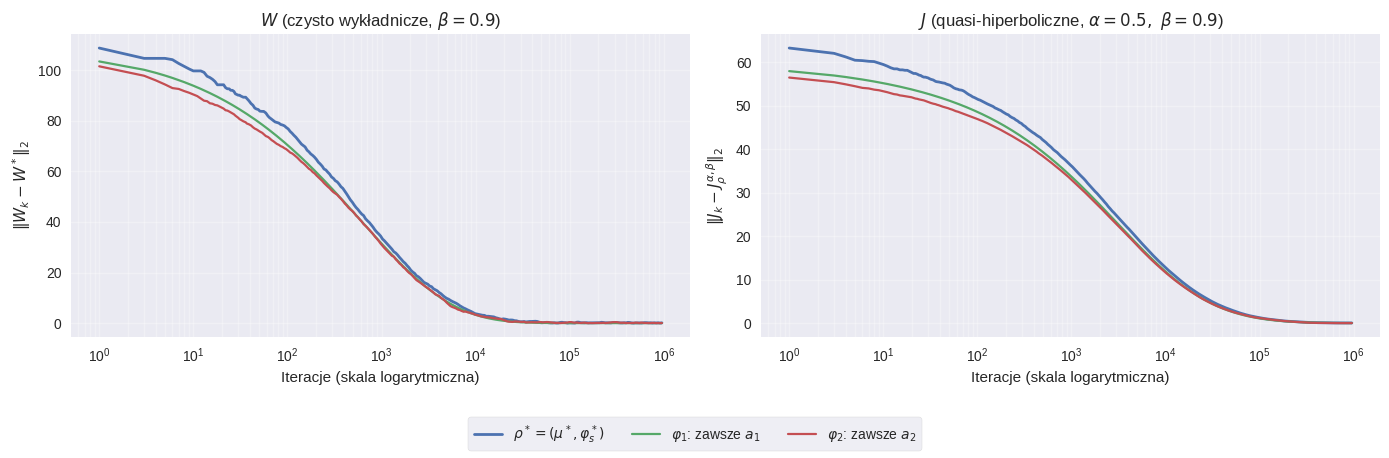

In [39]:
# ...existing code...

# ===============================================================
# 3b) Wykresy obok siebie (bez ponownego liczenia) — korzystamy z res_opt/res_inne
# ===============================================================

import matplotlib.pyplot as plt
import numpy as np

# Oś X (iteracje / sweeps) w punktach logowania.
x_opt_w = (log_idx[: len(res_opt["err_W"])] + 1).astype(float)
x_opt_j = (log_idx[: len(res_opt["err_J"])] + 1).astype(float)

fig, (ax_w, ax_j) = plt.subplots(1, 2, figsize=(14, 4.6), sharex=False, sharey=False)

# --- Panel: W ---
ax_w.plot(
    x_opt_w,
    res_opt["err_W"],
    label=r"$\rho^*=(\mu^*,\varphi_s^*)$",
    linewidth=2.0,
)
for name in wybrane:
    label = nazwy_polityk_pl.get(name, name)
    res = res_inne[name]
    x = (log_idx[: len(res["err_W"])] + 1).astype(float)
    ax_w.plot(x, res["err_W"], label=label, linewidth=1.6)

ax_w.set_xscale("log")
ax_w.set_xlabel("Iteracje (skala logarytmiczna)")
ax_w.set_ylabel(r"$\|W_k - W^*\|_2$")
ax_w.set_title(r"$W$ (czysto wykładnicze, $\beta=0.9$)")
ax_w.grid(True, which="both", alpha=0.3)

# --- Panel: J ---
ax_j.plot(
    x_opt_j,
    res_opt["err_J"],
    label=r"$\rho^*=(\mu^*,\varphi_s^*)$",
    linewidth=2.0,
)
for name in wybrane:
    label = nazwy_polityk_pl.get(name, name)
    res = res_inne[name]
    x = (log_idx[: len(res["err_J"])] + 1).astype(float)
    ax_j.plot(x, res["err_J"], label=label, linewidth=1.6)

ax_j.set_xscale("log")
ax_j.set_xlabel("Iteracje (skala logarytmiczna)")
ax_j.set_ylabel(r"$\|J_k - J^{\alpha,\beta}_{\rho}\|_2$")
ax_j.set_title(r"$J$ (quasi-hiperboliczne, $\alpha=0.5,\ \beta=0.9$)")
ax_j.grid(True, which="both", alpha=0.3)

# Jedna legenda dla całej figury (żeby nie dublować)
handles, labels = ax_j.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=True)

fig.tight_layout(rect=[0, 0.12, 1, 1])  # zostaw miejsce na legendę
plt.show()

# ...existing code...

## 3c) Policy evaluation (Alg. 1) — 100M od zera tylko dla polityki optymalnej $\rho^*$



Ta sekcja uruchamia Alg. 1 **od początku** tylko dla polityki optymalnej (bez liczenia pozostałych polityk) i rysuje zbieżność.

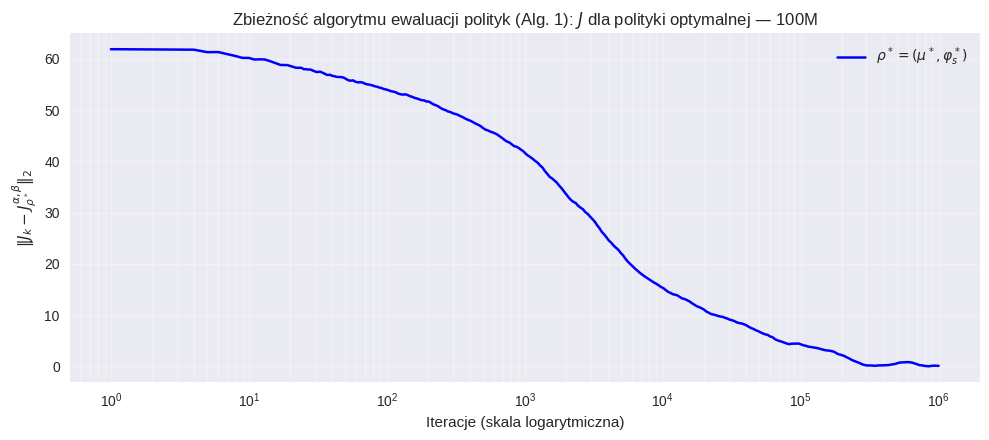

In [29]:
import numpy as np
import matplotlib.pyplot as plt

from src.algorithms.qh_policy_evaluation import QHPolicyEvaluation
from src.experiments.two_state_five_policies import TwoStateNinePoliciesMDP

# Parametry zgodne z rozdziałem eksperymentów.
mdp = TwoStateNinePoliciesMDP(alpha=0.5, beta=0.9)

# Liczba sweepów.
# Uwaga: bardzo duże wartości mogą trwać bardzo długo (w zależności od CPU / trybu notebooka).
n_sweeps = 1_000_000
n_log_points = 350

# Kroki uczące (Robbins–Monro): chcemy, żeby η_n i θ_n malały "wolno" -> wykładniki blisko 0.5.
# Jednocześnie wymagamy θ_exponent > η_exponent, żeby spełnić warunek dwóch skal czasowych (θ_n / η_n -> 0).
eta_step = 0.25
theta_step = 0.08
eta_exponent = 0.55
theta_exponent = 0.75

# Punkty logowania (log-spaced) dla czytelności na osi logarytmicznej.
log_idx = np.unique(np.logspace(0, np.log10(max(1, n_sweeps - 1)), n_log_points).astype(int))
log_idx[0] = 0
log_set = set(int(i) for i in log_idx)

plt.style.use("seaborn-v0_8")


def _P_i_r_i(mdp_obj: TwoStateNinePoliciesMDP, pol: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Indukuje (P_pol, r_pol) dla stanów {1,2} przy danej polityce (2x2).
    Akcje są w kolejności: a1, a2 (indeks 0 -> a1, 1 -> a2).
    """
    P_pol = np.zeros((2, 2), dtype=float)
    r_pol = np.zeros(2, dtype=float)
    for s_idx, s_mdp in enumerate([1, 2]):
        for a_idx, a_label in enumerate(["a1", "a2"]):
            p_a = float(pol[s_idx, a_idx])
            dist = mdp_obj.transitions[(s_mdp, a_label)]
            for sp_mdp, prob in dist.items():
                P_pol[s_idx, int(sp_mdp) - 1] += p_a * float(prob)
                r_pol[s_idx] += p_a * float(prob) * float(mdp_obj.reward(s_mdp, a_label, int(sp_mdp)))
    return P_pol, r_pol


def W_teoria(mdp_obj: TwoStateNinePoliciesMDP, varphi_s: np.ndarray) -> np.ndarray:
    """Wartość bazowa W^{varphi_s}(s): W = r_{varphi_s} + beta * P_{varphi_s} W."""
    P_phi, r_phi = _P_i_r_i(mdp_obj, varphi_s)
    return np.linalg.solve(np.eye(2) - mdp_obj.beta * P_phi, r_phi)


def J_teoria(mdp_obj: TwoStateNinePoliciesMDP, mu: np.ndarray, varphi_s: np.ndarray, W_phi: np.ndarray) -> np.ndarray:
    """Wartość quasi-hiperboliczna J^{alpha,beta}_{rho}(s) dla rho=(mu,varphi_s).
    J = r_mu + alpha*beta * P_mu W^{varphi_s}.
    """
    P_mu, r_mu = _P_i_r_i(mdp_obj, mu)
    return r_mu + (mdp_obj.alpha * mdp_obj.beta) * (P_mu @ W_phi)


def _nu_zapewnij_wsparcie(nu_bazowa: np.ndarray, mu: np.ndarray, varphi_s: np.ndarray, eps: float = 1e-2) -> np.ndarray:
    """Miesza nu z (mu, varphi_s), żeby zapewnić wspólne wsparcie dla wag istotności."""
    nu = (1.0 - 2.0 * eps) * nu_bazowa + eps * mu + eps * varphi_s
    return nu / nu.sum(axis=1, keepdims=True)


def _macierz_det(akcja_s1: int, akcja_s2: int) -> np.ndarray:
    """Deterministyczna macierz polityki 2x2 z akcji w {1,2} (1->a1, 2->a2)."""
    mat = np.zeros((2, 2), dtype=float)
    mat[0, int(akcja_s1) - 1] = 1.0
    mat[1, int(akcja_s2) - 1] = 1.0
    return mat


# Polityka optymalna dla 2-stanowego przykładu (zgodnie z wcześniejszą sekcją):
# mu*(1)=2, mu*(2)=1,  varphi_s*(1)=1, varphi_s*(2)=2
mu_star = _macierz_det(2, 1)
varphi_star = _macierz_det(1, 2)

# Teoria (punkt odniesienia) — potrzebne do błędu J
W_star = W_teoria(mdp, varphi_star)
J_star = J_teoria(mdp, mu_star, varphi_star, W_star)

# Polityka próbkowania nu: losowa 50/50, lekko zmieszana z (mu*, varphi*) dla wspólnego wsparcia
nu_bazowa = np.full((2, 2), 0.5, dtype=float)
nu = _nu_zapewnij_wsparcie(nu_bazowa, mu_star, varphi_star, eps=1e-2)

# Alg. 1 (policy evaluation) — ustawiamy wolno malejące kroki
# (w samym evaluatorze, więc _current_stepsizes() będzie już zgodne z tymi parametrami).
evaluator = QHPolicyEvaluation(
    n_states=2,
    alpha=mdp.alpha,
    beta=mdp.beta,
    eta_step=eta_step,
    theta_step=theta_step,
    eta_exponent=eta_exponent,
    theta_exponent=theta_exponent,
)
evaluator.reset()

rng_actions = np.random.default_rng(2026)
rng_sampler = np.random.default_rng(2026 + 999)
sampler = mdp.make_sampler(rng_sampler)

# Logujemy tylko błąd J
err_J = np.zeros(log_idx.shape[0], dtype=float)
pos = 0

# Opcjonalny „heartbeat” na stdout (rzadko, żeby nie spamować).
heartbeat_every = 10_000_000

for t in range(n_sweeps):
    # Jeden (eta_n, theta_n) na sweep: zgodnie z wersją synchroniczną (sweep) algorytmu.
    eta_n, theta_n = evaluator._current_stepsizes()  # noqa: SLF001

    for s in range(evaluator.n_states):
        # Akcja z polityki próbkowania nu (nie z mu).
        a = int(rng_actions.choice(2, p=nu[s]))
        sp, r, done = sampler(int(s), int(a))

        follow_r = 0.0
        if not done:
            a_follow = int(rng_actions.choice(2, p=varphi_star[int(sp)]))
            _, follow_r, _ = sampler(int(sp), int(a_follow))

        evaluator.update(
            state=int(s),
            action=int(a),
            reward=float(r),
            next_state=int(sp),
            follow_reward=float(follow_r),
            sampling_prob=float(nu[s, a]),
            mu_prob=float(mu_star[s, a]),
            phi_prob=float(varphi_star[s, a]),
            eta_n=float(eta_n),
            theta_n=float(theta_n),
        )

    evaluator._iteration += 1  # noqa: SLF001

    if t in log_set:
        err_J[pos] = float(np.linalg.norm(evaluator.J - J_star))
        pos += 1
        if pos >= len(log_idx):
            break

    if heartbeat_every and (t % heartbeat_every == 0) and t > 0:
        print(f"Progress: t={t:,} / {n_sweeps:,}")

# Oś X (iteracje / sweeps) w punktach logowania
x = (log_idx[:pos] + 1).astype(float)

plt.figure(figsize=(10, 4.5))
plt.plot(
    x,
    err_J[:pos],
    label=r"$\rho^*=(\mu^*,\varphi_s^*)$",
    linewidth=1.8,
    color="blue",
)
plt.xscale("log")
plt.xlabel("Iteracje (skala logarytmiczna)")
plt.ylabel(r"$\|J_k - J^{\alpha,\beta}_{\rho^*}\|_2$")
plt.title(r"Zbieżność algorytmu ewaluacji polityk (Alg. 1): $J$ dla polityki optymalnej — 100M")
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()


In [40]:
import numpy as np
import pandas as pd

from src.algorithms.qh_qlearning import QHQLearning, train_qh_qlearning_sweep
from src.experiments.two_state_five_policies import TwoStateNinePoliciesMDP

# QH Q-learning (Alg. 2) dla 2-stanowego MDP z rozdziału: α=0.5, β=0.9
mdp = TwoStateNinePoliciesMDP(alpha=0.5, beta=0.9)

# Generative model / sampler: (state_idx, action_idx) -> (next_state_idx, reward, done)
rng = np.random.default_rng(123)
sampler = mdp.make_sampler(rng)

# Agent (Alg. 2)
agent = QHQLearning(
    n_states=2,
    n_actions=2,
    alpha=mdp.alpha,
    beta=mdp.beta,
    # Harmonogramy kroków: umiarkowane wartości (quick run)
    theta_step=0.2,
    eta_step=0.4,
    theta_power=0.8,
    eta_power=0.6,
    step_offset=10.0,
    init_value=0.0,
 )

# Quick run: zwiększ jeśli chcesz lepszą dokładność (1 sweep = n_states*n_actions update'ów)
n_sweeps = 300_000
updates_per_sweep = agent.n_states * agent.n_actions
train_qh_qlearning_sweep(sampler=sampler, agent=agent, n_iterations=int(n_sweeps))
print(f"Done: {n_sweeps:,} sweeps (~{n_sweeps * updates_per_sweep:,} updates)")

# Mapowanie akcji: 0 -> a1, 1 -> a2
action_names = ["a1", "a2"]
state_names = [1, 2]  # w opisie MDP stany są 1..2

df_Q = pd.DataFrame(agent.Q, index=state_names, columns=action_names)
df_W = pd.DataFrame(agent.W, index=state_names, columns=action_names)

print("\nQ-table (rows=state, cols=action):")
display(df_Q.round(4))

print("\nW-table (rows=state, cols=action):")
display(df_W.round(4))

policy_first_step = np.argmax(agent.Q, axis=1)  # greedy po Q
policy_cont = np.argmax(agent.W, axis=1)        # greedy po W

print("\nGreedy first-step policy (argmax_a Q):")
print({state_names[i]: action_names[a] for i, a in enumerate(policy_first_step)})

print("Greedy continuation policy (argmax_a W):")
print({state_names[i]: action_names[a] for i, a in enumerate(policy_cont)})

Done: 300,000 sweeps (~1,200,000 updates)

Q-table (rows=state, cols=action):


,a1,a2
1,38.7935,38.8608
2,49.9136,49.3541



W-table (rows=state, cols=action):


,a1,a2
1,77.5537,75.7399
2,84.8034,86.1630



Greedy first-step policy (argmax_a Q):
{1: 'a2', 2: 'a1'}
Greedy continuation policy (argmax_a W):
{1: 'a1', 2: 'a2'}


## 4) `two_state_qlearning.py`

Ten skrypt implementuje QH Q-learning (Alg. 2) dla 2‑stanowego kontrprzykładu.

Uwaga: domyślnie trening ma `steps=300_000`. Poniżej robimy krótszy bieg (quick), żeby dało się to uruchamiać komfortowo w notebooku. Jeśli chcesz pełny bieg 1:1, uruchom komórkę „full run” na końcu sekcji.

In [21]:
#Full run (1:1 jak w skrypcie) — opcjonalnie:
out = run_module_inline_no_savefig("src.experiments.two_state_qlearning")
print(out)

--- QH Q-learning on two-state MDP (alpha=0.5, beta=0.8) ---
Q-table (rows=state, cols=action):
s=0:   18.839   18.951
s=1:   32.046   32.046

W-table (rows=state, cols=action):
s=0:   37.778   35.995
s=1:   47.222   47.222

Greedy policy (first-step, argmax_a Q):
[1 0]

Greedy continuation policy (argmax_a W):
[0 0]

Comparison to Table 1c targets (f/g/h share same numeric targets per (s,a)):
(s=0, a=0) -> est= 18.839 | target≈18.88
(s=0, a=1) -> est= 18.951 | target≈19.0
(s=1, a=0) -> est= 32.046 | target≈32.11


[stderr]
(empty)


## 4) `InventoryMDP.py`

Uruchomienie 1:1 jak w skrypcie. To jest długie (domyślnie `n_iterations = 5_000_000` i kilka seedów).
W notebooku przechwytujemy `plt.savefig(...)` i pokazujemy wykresy inline (bez zapisu na dysk).

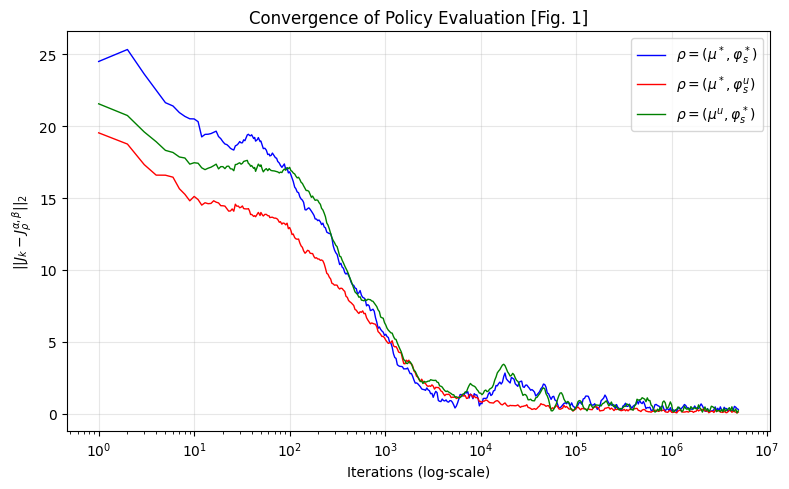


--- Running Optimal Control (High Precision Mode) ---

Optimal deterministic policies (found by exhaustive search):
mu* actions per state: [1, 0, 0]
phi_s* actions per state: [2, 1, 0]

QH Q-Value Function Q*_{mu*,phi_s*} (Profits):
s/a   0        1        2       
------------------------------
0         9.32    11.39    10.56
1        16.39    15.56    10.56
2        20.56    15.56    10.56

--- Running Policy Evaluation (Reproducing Fig 1) ---
Analytical J^{alpha, beta} for $\rho = (\mu^*, \varphi_s^*)$: [11.385 16.385 20.56 ]
Final J estimate for $\rho = (\mu^*, \varphi_s^*)$ (mean±std over 3 seeds): [11.43614535 16.45346643 20.56697366] ± [0.21689058 0.13465213 0.14183312]
Analytical J^{alpha, beta} for $\rho = (\mu^*, \varphi_s^u)$: [ 8.42312932 13.42312932 17.72406713]
Final J estimate for $\rho = (\mu^*, \varphi_s^u)$ (mean±std over 3 seeds): [ 8.42677658 13.41291561 17.67589909] ± [0.08340804 0.03630056 0.0616512 ]
Analytical J^{alpha, beta} for $\rho = (\mu^u, \varphi_s^*)$:

In [18]:
out = run_module_inline_no_savefig("src.experiments.InventoryMDP")
print(out)

## 4b) Inventory control (wariant M=3) — `InventoryMDP_M3.py`

In [ ]:
# Uruchamia wariant eksperymentu inventory (M=3) z pliku: src/experiments/InventoryMDP_M3.py
# Uwaga: w środku jest dość długi przebieg policy-evaluation (5e6 iteracji × 3 seedy × 3 scenariusze).
out = run_module_inline_no_savefig("src.experiments.InventoryMDP_M3")
print(out)

In [13]:
import random

# --- Parametry ZGODNE Z TWOIM OPISEM ---
ALPHA = 0.5   # Bias teraźniejszości (stały dla t>0)
BETA = 0.9    # Standardowy dyskont (potęgowany)
HORIZON = 20000 # Horyzont (przy 0.9 zbiega wolniej, więc dajemy bezpieczny zapas, choć w MC można i więcej)
N_ITERATIONS = 50000 # Więcej iteracji dla stabilności

def step(s, a):
    if s == 1:
        if a == 'a1': return 2, 0.0
        else: return (1, 2.0) if random.random() < 0.5 else (2, 2.0)
    elif s == 2:
        if a == 'a1': return 1, 15.0
        else: return (1, 20.0) if random.random() < 0.5 else (2, 5.0)
    return s, 0

def get_policy_action(s, policy_name):
    if policy_name == 'always_a1': return 'a1'
    elif policy_name == 'always_a2': return 'a2'
    elif policy_name == 'a1_s1_a2_s2': return 'a1' if s == 1 else 'a2'
    elif policy_name == 'a2_s1_a1_s2': return 'a2' if s == 1 else 'a1'
    elif policy_name == 'fifty_fifty': return 'a1' if random.random() < 0.5 else 'a2'
    return 'a1'

policies = ['always_a1', 'always_a2', 'a1_s1_a2_s2', 'a2_s1_a1_s2', 'fifty_fifty']
scenarios = [(1, 'a1'), (1, 'a2'), (2, 'a1'), (2, 'a2')]
results = {}

print(f"Start (Alpha={ALPHA} [bias], Beta={BETA} [exp])...")

for pol in policies:
    results[pol] = {}
    for start_s, start_a in scenarios:
        total_q = 0.0
        for _ in range(N_ITERATIONS):
            # t=0: Pełna nagroda
            s_next, r_imm = step(start_s, start_a)
            cumulative_reward = r_imm 
            
            # Przygotowanie do t=1
            current_s = s_next
            
            # W t=1 waga to ALPHA * BETA^1
            current_discount = ALPHA * BETA 
            
            for t in range(1, HORIZON + 1):
                a = get_policy_action(current_s, pol)
                s_next, r = step(current_s, a)
                
                cumulative_reward += r * current_discount
                
                current_s = s_next
                
                # KLUCZOWA ZMIANA:
                # Następna waga to ALPHA * BETA^2, więc mnożymy tylko przez BETA
                current_discount *= BETA 
                
                if current_discount < 1e-10: break
            
            total_q += cumulative_reward
        results[pol][(start_s, start_a)] = total_q / N_ITERATIONS

# Wyświetlenie
print("\n" + "="*85)
print(f"{'Para (s,a)':<12} | " + " | ".join([f"{p[:11]:<11}" for p in policies]))
print("-" * 85)
for s, a in scenarios:
    row = [f"{results[pol][(s, a)]:9.4f}" for pol in policies]
    print(f"({s}, {a}){' ':<5} | " + " | ".join(row))
print("="*85)

Start (Alpha=0.5 [bias], Beta=0.9 [exp])...

Para (s,a)   | always_a1   | always_a2   | a1_s1_a2_s2 | a2_s1_a1_s2 | fifty_fifty
-------------------------------------------------------------------------------------
(1, a1)      |   35.5263 |   35.0024 |   38.7929 |   31.2096 |   35.2047
(1, a2)      |   35.7487 |   34.6133 |   38.8502 |   31.2052 |   35.1978
(2, a1)      |   46.9737 |   45.2892 |   49.9143 |   42.1216 |   46.2176
(2, a2)      |   46.2280 |   45.1276 |   49.3511 |   41.6427 |   45.6741


In [14]:
import random

# --- Parametry ZGODNE Z TWOIM OPISEM ---
ALPHA = 1   # Bias teraźniejszości (stały dla t>0)
BETA = 0.9    # Standardowy dyskont (potęgowany)
HORIZON = 20000 # Horyzont (przy 0.9 zbiega wolniej, więc dajemy bezpieczny zapas, choć w MC można i więcej)
N_ITERATIONS = 50000 # Więcej iteracji dla stabilności

def step(s, a):
    if s == 1:
        if a == 'a1': return 2, 0.0
        else: return (1, 2.0) if random.random() < 0.5 else (2, 2.0)
    elif s == 2:
        if a == 'a1': return 1, 15.0
        else: return (1, 20.0) if random.random() < 0.5 else (2, 5.0)
    return s, 0

def get_policy_action(s, policy_name):
    if policy_name == 'always_a1': return 'a1'
    elif policy_name == 'always_a2': return 'a2'
    elif policy_name == 'a1_s1_a2_s2': return 'a1' if s == 1 else 'a2'
    elif policy_name == 'a2_s1_a1_s2': return 'a2' if s == 1 else 'a1'
    elif policy_name == 'fifty_fifty': return 'a1' if random.random() < 0.5 else 'a2'
    return 'a1'

policies = ['always_a1', 'always_a2', 'a1_s1_a2_s2', 'a2_s1_a1_s2', 'fifty_fifty']
scenarios = [(1, 'a1'), (1, 'a2'), (2, 'a1'), (2, 'a2')]
results = {}

print(f"Start (Alpha={ALPHA} [bias], Beta={BETA} [exp])...")

for pol in policies:
    results[pol] = {}
    for start_s, start_a in scenarios:
        total_q = 0.0
        for _ in range(N_ITERATIONS):
            # t=0: Pełna nagroda
            s_next, r_imm = step(start_s, start_a)
            cumulative_reward = r_imm 
            
            # Przygotowanie do t=1
            current_s = s_next
            
            # W t=1 waga to ALPHA * BETA^1
            current_discount = ALPHA * BETA 
            
            for t in range(1, HORIZON + 1):
                a = get_policy_action(current_s, pol)
                s_next, r = step(current_s, a)
                
                cumulative_reward += r * current_discount
                
                current_s = s_next
                
                # KLUCZOWA ZMIANA:
                # Następna waga to ALPHA * BETA^2, więc mnożymy tylko przez BETA
                current_discount *= BETA 
                
                if current_discount < 1e-10: break
            
            total_q += cumulative_reward
        results[pol][(start_s, start_a)] = total_q / N_ITERATIONS

# Wyświetlenie
print("\n" + "="*85)
print(f"{'Para (s,a)':<12} | " + " | ".join([f"{p[:11]:<11}" for p in policies]))
print("-" * 85)
for s, a in scenarios:
    row = [f"{results[pol][(s, a)]:9.4f}" for pol in policies]
    print(f"({s}, {a}){' ':<5} | " + " | ".join(row))
print("="*85)

Start (Alpha=1 [bias], Beta=0.9 [exp])...

Para (s,a)   | always_a1   | always_a2   | a1_s1_a2_s2 | a2_s1_a1_s2 | fifty_fifty
-------------------------------------------------------------------------------------
(1, a1)      |   71.0526 |   69.9809 |   77.5750 |   62.3868 |   70.3471
(1, a2)      |   69.4842 |   67.2548 |   75.6957 |   60.3344 |   68.3618
(2, a1)      |   78.9474 |   75.5138 |   84.8340 |   69.3189 |   77.4113
(2, a2)      |   79.9673 |   77.7712 |   86.1783 |   70.8526 |   78.8395


In [5]:
import numpy as np
import pandas as pd

from src.algorithms.qh_qlearning import QHQLearning, train_qh_qlearning_sweep

# ---------------------------------------------------------------
# Inventory Control (wariant M=3) — TYLKO QH Q-learning (Alg. 2)
# Parametry zgodne z: src/experiments/InventoryMDP_M3.py
# ---------------------------------------------------------------

M = 3
c = 6
h = 3
p = 11

demand_values = np.array([0, 1, 2, 3], dtype=int)
demand_probs = np.array([0.1, 0.2, 0.3, 0.4], dtype=float)

alpha = 0.35
beta = 0.95

n_states = M + 1   # stany: poziom zapasu 0..M
n_actions = M + 1  # akcje: zamówienie 0..M

rng = np.random.default_rng(2026)

def sampler(state: int, action: int):
    # Stan = bieżący stan zapasu (0..M). Akcja = zamówienie (0..M).
    s = int(state)
    a = int(action)
    s_hat = min(s + a, M)
    d = int(rng.choice(demand_values, p=demand_probs))
    next_state = max(s_hat - d, 0)

    cost = c * a + h * max(s_hat - d, 0) - p * min(s_hat, d)
    reward = -float(cost)
    done = False
    return int(next_state), reward, bool(done)

# Agent (Alg. 2) — harmonogramy jak w wariancie M3
agent = QHQLearning(
    n_states=n_states,
    n_actions=n_actions,
    alpha=alpha,
    beta=beta,
    theta_step=0.2,
    eta_step=0.4,
    theta_power=0.8,
    eta_power=0.6,
    step_offset=10.0,
    init_value=0.0,
 )

# Trening (light): liczba aktualizacji ~ episodes
episodes = 100_000_000
updates_per_sweep = n_states * n_actions
n_sweeps = max(1, int(episodes) // int(updates_per_sweep))
train_qh_qlearning_sweep(sampler=sampler, agent=agent, n_iterations=int(n_sweeps))
print(f"Done: {n_sweeps:,} sweeps (~{n_sweeps * updates_per_sweep:,} updates)")

# Tabele Q(s,a) i W(s,a)
state_names = list(range(n_states))
action_names = list(range(n_actions))

df_Q = pd.DataFrame(agent.Q, index=state_names, columns=action_names)
df_W = pd.DataFrame(agent.W, index=state_names, columns=action_names)

print("\nQ(s,a):")
display(df_Q.round(4))

print("\nW(s,a):")
display(df_W.round(4))

Done: 6,250,000 sweeps (~100,000,000 updates)

Q(s,a):


,0,1,2,3
0,44.6349,48.4375,49.8316,47.6371
1,54.4310,55.8304,53.6284,47.6284
2,61.8311,59.6326,53.6321,47.6324
3,65.6328,59.6270,53.6232,47.6306



W(s,a):


,0,1,2,3
0,127.4992,131.6772,134.2060,134.1781
1,137.6581,140.1643,140.2175,134.2134
2,146.1939,146.1299,140.2028,134.1548
3,152.2200,146.2367,140.1319,134.2182


## 4c) Inventory M=3 — Policy evaluation (Alg. 1) dla 3 przypadków i wykres zbieżności

- Polityka próbkowania $\nu=v$: losowa jednostajna po akcjach wykonalnych ($s+a\le M$).
- Badane pary $\rho=(\mu,\varphi_s)$:
  1) $(\mu^*,\varphi^*)$ z QH Q-learning (greedy po $Q$ i $W$),
  2) $(v,\varphi^*)$,
  3) $(\mu^*,v)$.

> Uwaga: w tej sekcji **nie mieszamy** wsparcia (`adjust_support=False`), więc wszystkie polityki mają masę tylko na wykonalnych akcjach.

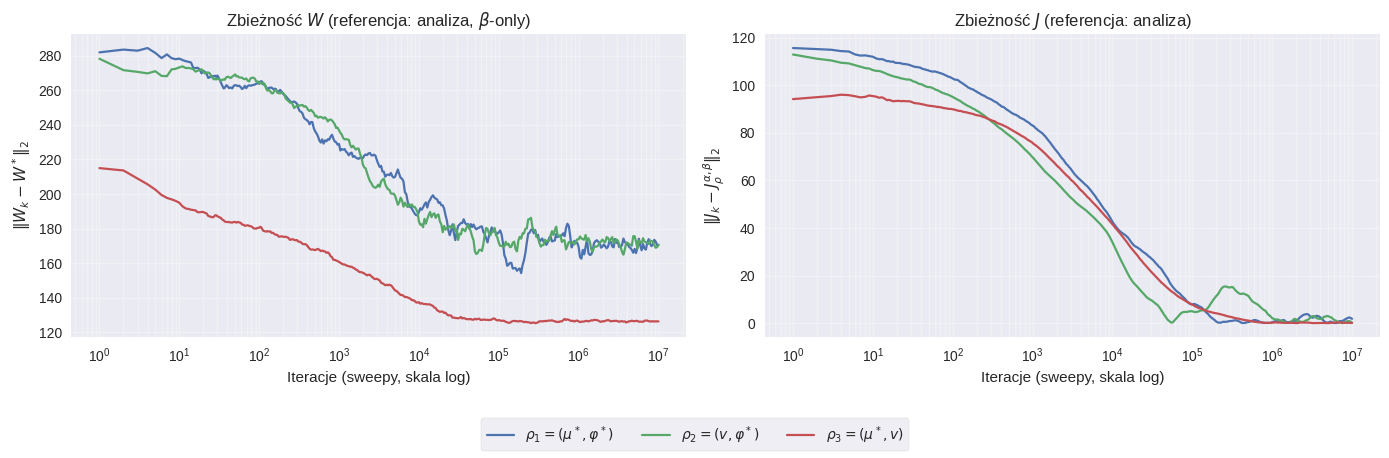


Sampling policy nu=v (rows=state, cols=order a=0..M):


,0,1,2,3
0,0.250,0.250,0.250,0.25
1,0.333,0.333,0.333,0.00
2,0.500,0.500,0.000,0.00
3,1.000,0.000,0.000,0.00



Podsumowanie końcowych błędów norm (po n_iterations):


,case,||W_hat - W*||_2 (final),||J_hat - J*||_2 (final)
0,"$\rho_1=(\mu^*,\varphi^*)$",170.604431,1.834429
1,"$\rho_2=(v,\varphi^*)$",170.406849,0.247221
2,"$\rho_3=(\mu^*,v)$",126.243309,0.088317


In [6]:
import numpy as np
import pandas as pd

from src.algorithms.qh_policy_evaluation import QHPolicyEvaluation

# Zakładamy, że parametry Inventory M=3 i obiekt `agent` (QH Q-learning) są z poprzedniej komórki.
# Jeśli uruchamiasz tę komórkę osobno, najpierw odpal komórkę z Q-learningiem dla M=3.
M = 3
c = 6
h = 3
p = 11
assert M == 3
assert n_states == M + 1
assert n_actions == M + 1

# ----------------------------
# 1) Sampling policy: ν=v
# ----------------------------
def feasible_actions_mask(s: int) -> np.ndarray:
    mask = np.zeros(n_actions, dtype=bool)
    mask[: (M - int(s) + 1)] = True
    return mask

def make_v_policy() -> np.ndarray:
    v = np.zeros((n_states, n_actions), dtype=float)
    for s in range(n_states):
        mask = feasible_actions_mask(s)
        v[s, mask] = 1.0 / float(mask.sum())
    return v

nu = make_v_policy()
print("Sampling policy nu=v (rows=state, cols=action a=0..M):")
display(pd.DataFrame(nu, index=list(range(n_states)), columns=list(range(n_actions))).round(3))

# ----------------------------
# 2) Trzy badane polityki ρ=(μ,φ_s)
# ----------------------------
def greedy_feasible_from_table(table: np.ndarray) -> np.ndarray:
    pol = np.zeros((n_states, n_actions), dtype=float)
    for s in range(n_states):
        mask = feasible_actions_mask(s)
        vals = np.asarray(table[s], dtype=float).copy()
        vals[~mask] = -np.inf
        a_star = int(np.argmax(vals))
        pol[s, a_star] = 1.0
    return pol

mu_star = greedy_feasible_from_table(agent.Q)
phi_star = greedy_feasible_from_table(agent.W)

cases = [
    (r"$\rho_1=(\mu^*,\varphi^*)$", mu_star, phi_star, 2026),
    (r"$\rho_2=(v,\varphi^*)$", nu, phi_star, 3026),
    (r"$\rho_3=(\mu^*,v)$", mu_star, nu, 4026),
]

def as_argmax_actions(policy: np.ndarray) -> list[int]:
    return [int(np.argmax(policy[s])) for s in range(n_states)]

print("\nBadane przypadki (argmax po rozkładzie w stanie):")
for label, mu_i, phi_i, _seed in cases:
    print(f"- {label}: mu={as_argmax_actions(mu_i)}, phi={as_argmax_actions(phi_i)}")

# ----------------------------
# Referencje analityczne: W* i J* (dla wykresu zbieżności)
# ----------------------------
def get_dynamics_matrices() -> tuple[np.ndarray, np.ndarray]:
    P = np.zeros((n_states, n_actions, n_states), dtype=float)
    R = np.zeros((n_states, n_actions), dtype=float)
    for s in range(n_states):
        for a in range(n_actions):
            expected_reward = 0.0
            s_hat = min(int(s) + int(a), M)
            for d_idx, d in enumerate(demand_values):
                prob = float(demand_probs[d_idx])
                d_int = int(d)
                s_next = max(s_hat - d_int, 0)
                cost = c * int(a) + h * max(s_hat - d_int, 0) - p * min(s_hat, d_int)
                r = -float(cost)
                expected_reward += prob * r
                P[s, a, s_next] += prob
            R[s, a] = expected_reward
    return P, R

P, R = get_dynamics_matrices()
I = np.eye(n_states)

def induce(policy: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    P_ind = np.zeros((n_states, n_states), dtype=float)
    r_ind = np.zeros(n_states, dtype=float)
    for s in range(n_states):
        P_ind[s] = (policy[s, :, None] * P[s]).sum(axis=0)
        r_ind[s] = float((policy[s] * R[s]).sum())
    return P_ind, r_ind

def W_ref(phi: np.ndarray) -> np.ndarray:
    P_phi, r_phi = induce(phi)
    return np.linalg.solve(I - beta * P_phi, r_phi)

def J_ref(mu: np.ndarray, phi: np.ndarray) -> np.ndarray:
    W_phi = W_ref(phi)
    P_mu, r_mu = induce(mu)
    return r_mu + (alpha * beta) * (P_mu @ W_phi)

def make_sampler(seed: int):
    rng = np.random.default_rng(seed)

    def _sampler(state: int, action: int):
        s = int(state)
        a = int(action)
        s_hat = min(s + a, M)
        d = int(rng.choice(demand_values, p=demand_probs))
        next_state = max(s_hat - d, 0)
        cost = c * a + h * max(s_hat - d, 0) - p * min(s_hat, d)
        reward = -float(cost)
        done = False
        return int(next_state), float(reward), bool(done)

    return _sampler

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# 3) Policy evaluation + wykres zbieżności -> docs/plots/ex2Plots.png
# ----------------------------
n_iterations = 10_000_000
n_log_points = 400
log_idx = np.unique(np.logspace(0, np.log10(max(2, n_iterations)), n_log_points).astype(int))
log_idx[0] = 1
log_idx = log_idx[log_idx <= n_iterations]
x = log_idx.astype(float)

plt.style.use("seaborn-v0_8")
fig, (ax_w, ax_j) = plt.subplots(1, 2, figsize=(14, 4.6))

# Zachowujemy krzywe do ponownego rysowania (np. w kolejnej komórce tylko J)
err_W_curves: dict[str, np.ndarray] = {}
err_J_curves: dict[str, np.ndarray] = {}

rows = []
for label, mu_i, phi_i, seed in cases:
    W_star = W_ref(phi_i)
    J_star = J_ref(mu_i, phi_i)

    # W-kryterium zbieżności
    ev_w = QHPolicyEvaluation(
    	 n_states=n_states,
        alpha=alpha,
        beta=beta,
        eta_step=0.25,
        theta_step=0.08,
        eta_exponent=0.55,
        theta_exponent=0.75,
    )
    res_w = ev_w.evaluate_policy(
        sampler=make_sampler(seed + 111),
        sampling_policy=nu,
        mu_policy=mu_i,
        phi_policy=phi_i,
        n_iterations=n_iterations,
        rng=np.random.default_rng(seed + 222),
        reference_values=W_star,
        reference_kind="W",
        adjust_support=False,
    )
    err_w = res_w["reference_diff"][log_idx - 1]
    err_W_curves[label] = err_w
    ax_w.plot(x, err_w, label=label, linewidth=1.6)

    # J-kryterium zbieżności
    ev_j = QHPolicyEvaluation(
        n_states=n_states,
        alpha=alpha,
        beta=beta,
        eta_step=0.25,
        theta_step=0.08,
        eta_exponent=0.55,
        theta_exponent=0.75,
    )
    res_j = ev_j.evaluate_policy(
        sampler=make_sampler(seed + 333),
        sampling_policy=nu,
        mu_policy=mu_i,
        phi_policy=phi_i,
        n_iterations=n_iterations,
        rng=np.random.default_rng(seed + 444),
        reference_values=J_star,
        reference_kind="J",
        adjust_support=False,
    )
    err_j = res_j["reference_diff"][log_idx - 1]
    err_J_curves[label] = err_j
    ax_j.plot(x, err_j, label=label, linewidth=1.6)

    rows.append(
        {
            "case": label,
            "||W_hat - W*||_2 (final)": float(np.linalg.norm(res_w["W"] - W_star)),
            "||J_hat - J*||_2 (final)": float(np.linalg.norm(res_j["J"] - J_star)),
        }
    )

ax_w.set_xscale("log")
ax_w.set_xlabel("Iteracje (sweepy, skala log)")
ax_w.set_ylabel(r"$\|W_k - W^*\|_2$")
ax_w.set_title(r"Zbieżność $W$ (referencja: analiza, $\beta$-only)")
ax_w.grid(True, which="both", alpha=0.3)

ax_j.set_xscale("log")
ax_j.set_xlabel("Iteracje (sweepy, skala log)")
ax_j.set_ylabel(r"$\|J_k - J^{\alpha,\beta}_\rho\|_2$")
ax_j.set_title(r"Zbieżność $J$ (referencja: analiza)")
ax_j.grid(True, which="both", alpha=0.3)

handles, labels = ax_j.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=True)
fig.tight_layout(rect=[0, 0.12, 1, 1])

repo_root = Path(globals().get("REPO_ROOT", Path.cwd()))
out_path = (repo_root / "docs" / "plots" / "ex2Plots.png").resolve()
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=200)
plt.show()

print(f"\nSaved: {out_path}")
print("\nPodsumowanie końcowych błędów norm (po n_iterations):")
display(pd.DataFrame(rows).round(6))


Sampling policy nu=v (rows=state, cols=order a=0..M):


,0,1,2,3
0,0.250,0.250,0.250,0.25
1,0.333,0.333,0.333,0.00
2,0.500,0.500,0.000,0.00
3,1.000,0.000,0.000,0.00



Podsumowanie końcowych błędów norm (po n_iterations):


,case,||W_hat - W*||_2 (final),||J_hat - J*||_2 (final)
0,"$\rho_1=(\mu^*,\varphi^*)$",170.604431,1.834429
1,"$\rho_2=(v,\varphi^*)$",170.406849,0.247221
2,"$\rho_3=(\mu^*,v)$",126.243309,0.088317


In [7]:
import matplotlib.pyplot as plt

# Ten wykres korzysta z krzywych policzonych w poprzedniej komórce:
# - x (iteracje, log-space)
# - err_J_curves[label] (normy błędu dla J)

if "err_J_curves" not in globals() or "x" not in globals():
    raise RuntimeError(
        "Brak err_J_curves/x w pamięci. Najpierw uruchom poprzednią komórkę z policy evaluation i zbieżnością."
    )

plt.style.use("seaborn-v0_8")
fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.6))

for label, curve in err_J_curves.items():
    ax.plot(x, curve, label=label, linewidth=1.8)

ax.set_xscale("log")
ax.set_xlabel("Iteracje (sweepy, skala log)")
ax.set_ylabel(r"$\|J_k - J^{\alpha,\beta}_\rho\|_2$")
ax.set_title(r"Zbieżność $J$ (referencja: analiza)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best", frameon=True)

fig.tight_layout()
plt.show()


RuntimeError: Brak err_J_curves/x w pamięci. Najpierw uruchom poprzednią komórkę z policy evaluation i zbieżnością.